# DeMemte Variants: Robustez al Ruido

Tres variantes arquitectónicas diseñadas a partir del análisis XAI que reveló:
1. El VAE no sabe reconstruir features ruidosos → **Variante 1: Denoising-VAE (D-VAE)**
2. El gating exponencial colapsa la señal con ruido → **Variante 2: Robust Gating**
3. El VAE pierde información espacial al aplanar → **Variante 3: Spatial ConvVAE**

Cada variante se entrena en Flowers102 con inyección de ruido durante entrenamiento,
y se evalúa en clean y noisy para comparar contra el DeMemte original (V1).

In [1]:
import os
import random
import time
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Componentes compartidos

In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, hard_threshold: float = 0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))
        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x):
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f'x debe ser (B, {self.in_features})')
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft
        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    def sparsity_loss(self):
        return torch.sigmoid(self.logits / self.temperature).mean()


class VAE(nn.Module):
    """VAE estándar con capas lineales (usado como memoria en DeMemte V1)."""
    def __init__(self, input_dim, output_dim, latent_dim=128):
        super().__init__()
        self.input_dim = input_dim
        self.fc1 = LearnedSparseLinear(input_dim, 400)
        self.fc21 = LearnedSparseLinear(400, latent_dim)
        self.fc22 = LearnedSparseLinear(400, latent_dim)
        self.fc3 = LearnedSparseLinear(latent_dim, 400)
        self.fc4 = LearnedSparseLinear(400, output_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.fc4(F.relu(self.fc3(z)))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def make_backbone():
    """Backbone ResNet-18 congelado que retorna vector 512-d."""
    base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-1], nn.Flatten())
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()
    return backbone


def make_spatial_backbone():
    """Backbone ResNet-18 congelado que retorna tensor espacial [B, 512, 7, 7]."""
    base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-2])  # antes de avgpool y fc
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()
    return backbone


EMBEDDING_DIM = 512
NUM_CLASSES = 102
LATENT_DIM = 128
print('Componentes compartidos definidos.')

Componentes compartidos definidos.


## DeMemte V1 (Original) — referencia

In [3]:
class DeMemteV1(nn.Module):
    """DeMemte original: VAE lineal + gating exponencial."""
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vae = vae
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x, clean_features=None):
        with torch.no_grad():
            raw = self.backbone(x)
        features = self.feat_norm(raw)
        x_rec, mu, logvar = self.vae(features)
        recon_loss = ((features - x_rec) ** 2).mean(dim=1, keepdim=True)
        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_loss * gamma)
        enhanced = features + self.memory_scale * signal * x_rec
        logits = self.classifier(enhanced)
        return logits, x_rec, mu, logvar, features

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

print('DeMemteV1 definido.')

DeMemteV1 definido.


## Variante 1: Denoising-VAE (D-VAE)

**Problema:** El VAE original reconstruye X ruidoso a partir de X ruidoso → no filtra ruido.

**Solución:** Durante entrenamiento, el VAE recibe features ruidosos pero su target de
reconstrucción son los features limpios. Así la memoria aprende activamente a denoiser.

In [4]:
class DeMemte_DVAE(nn.Module):
    """DeMemte con Denoising-VAE: la reconstrucción apunta a features limpios."""
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vae = vae
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x, clean_features=None):
        """
        Args:
            x: imágenes de entrada (pueden ser ruidosas)
            clean_features: (solo training) features limpios como target del VAE.
                           Si es None, se usan los features de x como target (modo V1).
        """
        with torch.no_grad():
            raw = self.backbone(x)
        features = self.feat_norm(raw)

        x_rec, mu, logvar = self.vae(features)

        # En training usamos clean_features como target; en eval usamos features
        target = clean_features if clean_features is not None else features
        recon_loss = ((target - x_rec) ** 2).mean(dim=1, keepdim=True)

        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_loss * gamma)

        enhanced = features + self.memory_scale * signal * x_rec
        logits = self.classifier(enhanced)

        return logits, x_rec, mu, logvar, features, target

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

print('DeMemte_DVAE definido.')

DeMemte_DVAE definido.


## Variante 2: Robust Gating

**Problema:** `exp(-gamma * recon_loss)` colapsa a ~0 cuando recon_loss sube con ruido → apaga la memoria.

**Solución:** Normalizar el recon_loss por batch y usar una sigmoidea con umbral aprendido.
Esto mantiene la señal en rango útil (~0.3–0.7) incluso con ruido extremo.

In [5]:
class DeMemte_RobustGate(nn.Module):
    """DeMemte con gating normalizado por batch: la señal no colapsa con ruido."""
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vae = vae
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)
        # Gating robusto: umbral y pendiente aprendidos
        self.gate_tau = nn.Parameter(torch.tensor([0.0]))    # umbral normalizado
        self.gate_alpha = nn.Parameter(torch.tensor([2.0]))  # pendiente

    def forward(self, x, clean_features=None):
        with torch.no_grad():
            raw = self.backbone(x)
        features = self.feat_norm(raw)
        x_rec, mu, logvar = self.vae(features)

        recon_loss = ((features - x_rec) ** 2).mean(dim=1, keepdim=True)

        # Normalización robusta por batch
        center = recon_loss.mean(dim=0, keepdim=True)
        scale = recon_loss.std(dim=0, keepdim=True) + 1e-6
        recon_norm = (recon_loss - center) / scale

        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (self.gate_tau - recon_norm))

        enhanced = features + self.memory_scale * signal * x_rec
        logits = self.classifier(enhanced)

        return logits, x_rec, mu, logvar, features

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

print('DeMemte_RobustGate definido.')

DeMemte_RobustGate definido.


## Variante 3: Spatial ConvVAE

**Problema:** Aplanar features a un vector 512-d destruye la topología espacial → el Grad-CAM
pierde foco con ruido.

**Solución:** Aplicar un VAE convolucional sobre el tensor `[B, 512, 7, 7]` (antes del AvgPool).
Esto preserva la estructura espacial y permite que la memoria reconstruya parches locales.

In [6]:
class ConvVAE(nn.Module):
    """VAE convolucional para tensores espaciales [B, C, H, W]."""
    def __init__(self, channels=512, latent_dim=128, spatial=7):
        super().__init__()
        self.channels = channels
        self.spatial = spatial

        # Encoder convolucional
        self.enc = nn.Sequential(
            nn.Conv2d(channels, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        flat_dim = 128 * spatial * spatial  # 128 * 7 * 7 = 6272
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, flat_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, channels, 3, padding=1),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, self.spatial, self.spatial)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


class DeMemte_Spatial(nn.Module):
    """DeMemte con VAE convolucional que opera en espacio [B,512,7,7]."""
    def __init__(self, spatial_backbone, conv_vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = spatial_backbone  # retorna [B, 512, 7, 7]
        self.conv_vae = conv_vae
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x, clean_features=None):
        with torch.no_grad():
            spatial_feats = self.backbone(x)  # [B, 512, 7, 7]

        # Reconstrucción espacial
        spatial_rec, mu, logvar = self.conv_vae(spatial_feats)

        # Señal de memoria por posición espacial, luego promedio
        recon_diff_spatial = ((spatial_feats - spatial_rec) ** 2).mean(dim=1, keepdim=True)  # [B,1,7,7]
        gamma = F.softplus(self.signal_gamma)
        signal_spatial = torch.exp(-recon_diff_spatial * gamma)  # [B,1,7,7]

        enhanced_spatial = spatial_feats + self.memory_scale * signal_spatial * spatial_rec  # [B,512,7,7]

        # Pool a vector y clasificar
        features = self.pool(spatial_feats).flatten(1)        # [B, 512]
        enhanced = self.pool(enhanced_spatial).flatten(1)     # [B, 512]

        features = self.feat_norm(features)
        enhanced = self.feat_norm(enhanced)

        logits = self.classifier(enhanced)

        # Para compatibilidad con la loss, x_rec es el pool de la reconstrucción
        x_rec = self.pool(spatial_rec).flatten(1)

        return logits, x_rec, mu, logvar, features

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

print('ConvVAE y DeMemte_Spatial definidos.')

ConvVAE y DeMemte_Spatial definidos.


## Datos y utilidades de entrenamiento

In [7]:
batch_size = 64
data_dir = '../data'

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset = torchvision.datasets.Flowers102(root=data_dir, split='train', download=True, transform=transform_train)
testset = torchvision.datasets.Flowers102(root=data_dir, split='test', download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Train: {len(trainset)} | Test: {len(testset)}')


def add_gaussian_noise(x, std=0.5):
    """Inyecta ruido gaussiano a un tensor de imágenes."""
    return x + torch.randn_like(x) * std

Train: 1020 | Test: 6149


In [8]:
def compute_loss(logits, labels, x_rec, features, mu, logvar, model,
                 sparsity_weight=0.002, vae_weight=0.1):
    """Loss unificada para todas las variantes."""
    task = F.cross_entropy(logits, labels)
    recon = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    vae_loss = recon + kld

    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task + vae_weight * vae_loss + sparsity_weight * s_loss


def compute_loss_dvae(logits, labels, x_rec, target_features, mu, logvar, model,
                      sparsity_weight=0.002, vae_weight=0.1):
    """Loss para D-VAE: la reconstrucción se compara contra los features limpios."""
    task = F.cross_entropy(logits, labels)
    recon = F.mse_loss(x_rec, target_features, reduction='sum') / target_features.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / target_features.size(0)
    vae_loss = recon + kld

    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task + vae_weight * vae_loss + sparsity_weight * s_loss


def unwrap_state_dict(ckpt):
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        return ckpt['model_state_dict']
    return ckpt

print('Funciones de loss definidas.')

Funciones de loss definidas.


## Inicialización de modelos

Cargamos los pesos del DeMemte V1 original (entrenado en Flowers102) como punto de partida para
las variantes, transfiriendo pesos compatibles.

In [9]:
def transfer_compatible_weights(target_model, source_state_dict):
    """Transfiere solo pesos con forma compatible."""
    dst = target_model.state_dict()
    transferred = 0
    for k, v in source_state_dict.items():
        if k in dst and dst[k].shape == v.shape:
            dst[k] = v
            transferred += 1
    target_model.load_state_dict(dst)
    return transferred

# Cargar checkpoint V1
v1_ckpt = unwrap_state_dict(torch.load('../out/dememte_optimized_flowers102/dememte_optimized_flowers102.pth', map_location=device))

# --- V1 (referencia) ---
model_v1 = DeMemteV1(make_backbone(), VAE(EMBEDDING_DIM, EMBEDDING_DIM, LATENT_DIM), EMBEDDING_DIM, NUM_CLASSES).to(device)
model_v1.load_state_dict(v1_ckpt)
model_v1.eval()
print(f'V1 cargado (referencia, no se entrena).')

# --- Variante 1: D-VAE ---
model_dvae = DeMemte_DVAE(make_backbone(), VAE(EMBEDDING_DIM, EMBEDDING_DIM, LATENT_DIM), EMBEDDING_DIM, NUM_CLASSES).to(device)
n = transfer_compatible_weights(model_dvae, v1_ckpt)
print(f'D-VAE: {n} pesos transferidos de V1.')

# --- Variante 2: Robust Gating ---
model_robust = DeMemte_RobustGate(make_backbone(), VAE(EMBEDDING_DIM, EMBEDDING_DIM, LATENT_DIM), EMBEDDING_DIM, NUM_CLASSES).to(device)
n = transfer_compatible_weights(model_robust, v1_ckpt)
print(f'RobustGate: {n} pesos transferidos de V1.')

# --- Variante 3: Spatial ConvVAE ---
conv_vae = ConvVAE(channels=512, latent_dim=LATENT_DIM, spatial=7)
model_spatial = DeMemte_Spatial(make_spatial_backbone(), conv_vae, EMBEDDING_DIM, NUM_CLASSES).to(device)
# Solo podemos transferir classifier, feat_norm, signal_gamma, memory_scale
n = transfer_compatible_weights(model_spatial, v1_ckpt)
print(f'Spatial: {n} pesos transferidos de V1 (backbone + classifier + norm).')

V1 cargado (referencia, no se entrena).
D-VAE: 142 pesos transferidos de V1.
RobustGate: 141 pesos transferidos de V1.
Spatial: 127 pesos transferidos de V1 (backbone + classifier + norm).


## Entrenamiento

Cada variante se entrena con inyección de ruido gaussiano (`std=0.3`) para que
las mejoras al gating y al denoising tengan oportunidad de activarse.

In [10]:
EPOCHS = 15
NOISE_STD = 0.3


def make_optimizer(model, lr_vae=3e-5, lr_cls=1e-2):
    """Optimizador con LRs separados como el V1 optimizado."""
    param_groups = []
    vae_params = []
    cls_params = []
    other_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if 'vae' in name or 'conv_vae' in name:
            vae_params.append(p)
        elif 'classifier' in name:
            cls_params.append(p)
        else:
            other_params.append(p)

    if vae_params:
        param_groups.append({'params': vae_params, 'lr': lr_vae})
    if cls_params:
        param_groups.append({'params': cls_params, 'lr': lr_cls})
    if other_params:
        param_groups.append({'params': other_params, 'lr': lr_cls})

    return optim.Adam(param_groups)


def train_variant(model, name, trainloader, testloader, epochs=EPOCHS,
                  noise_std=NOISE_STD, is_dvae=False):
    """Bucle de entrenamiento genérico para todas las variantes."""
    optimizer = make_optimizer(model)
    history = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0.0

        # Temperatura annealing para sparse gates
        temp = max(0.3, 1.0 - 0.05 * epoch)
        for m in model.modules():
            if isinstance(m, LearnedSparseLinear):
                m.temperature = temp

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Inyectar ruido al 50% de los batches para aprender de ambos
            use_noise = random.random() < 0.5
            if use_noise:
                noisy_inputs = add_gaussian_noise(inputs, std=noise_std)
            else:
                noisy_inputs = inputs

            optimizer.zero_grad()

            if is_dvae:
                # Para D-VAE: obtener features limpios como target
                with torch.no_grad():
                    clean_feats = model.feat_norm(model.backbone(inputs))
                logits, x_rec, mu, logvar, features, target = model(noisy_inputs, clean_features=clean_feats)
                loss = compute_loss_dvae(logits, labels, x_rec, target, mu, logvar, model)
            else:
                out = model(noisy_inputs)
                logits, x_rec, mu, logvar, features = out[:5]
                loss = compute_loss(logits, labels, x_rec, features, mu, logvar, model)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, pred = logits.max(1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        train_acc = 100 * correct / total

        # Eval clean y noisy
        clean_acc = evaluate_variant(model, testloader, noise_std=0.0, is_dvae=is_dvae)
        noisy_acc = evaluate_variant(model, testloader, noise_std=0.5, is_dvae=is_dvae)

        history['train_acc'].append(train_acc)
        history['clean_acc'].append(clean_acc)
        history['noisy_acc'].append(noisy_acc)

        print(f'[{name}] Epoch {epoch+1}/{epochs} | '
              f'Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

    return history


@torch.no_grad()
def evaluate_variant(model, loader, noise_std=0.0, is_dvae=False):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if noise_std > 0:
            x = add_gaussian_noise(x, std=noise_std)
        if is_dvae:
            logits = model(x)[0]
        else:
            logits = model(x)[0]
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return 100 * correct / total

print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


In [11]:
# Evaluar V1 original (sin reentrenamiento) como baseline
v1_clean = evaluate_variant(model_v1, testloader, noise_std=0.0)
v1_noisy = evaluate_variant(model_v1, testloader, noise_std=0.5)
print(f'V1 Original  | Clean: {v1_clean:.2f}% | Noisy (std=0.5): {v1_noisy:.2f}%')
print('---')

V1 Original  | Clean: 79.17% | Noisy (std=0.5): 34.49%
---


In [12]:
print('=== Entrenando Variante 1: D-VAE ===')
history_dvae = train_variant(model_dvae, 'D-VAE', trainloader, testloader, is_dvae=True)

=== Entrenando Variante 1: D-VAE ===
[D-VAE] Epoch 1/15 | Train: 83.3% | Clean: 70.8% | Noisy: 43.6%
[D-VAE] Epoch 2/15 | Train: 93.6% | Clean: 75.9% | Noisy: 48.9%
[D-VAE] Epoch 3/15 | Train: 95.1% | Clean: 77.2% | Noisy: 52.0%
[D-VAE] Epoch 4/15 | Train: 98.3% | Clean: 75.5% | Noisy: 52.0%
[D-VAE] Epoch 5/15 | Train: 98.0% | Clean: 76.5% | Noisy: 56.0%
[D-VAE] Epoch 6/15 | Train: 98.8% | Clean: 76.7% | Noisy: 55.8%
[D-VAE] Epoch 7/15 | Train: 99.0% | Clean: 77.7% | Noisy: 58.0%
[D-VAE] Epoch 8/15 | Train: 99.3% | Clean: 76.7% | Noisy: 58.3%
[D-VAE] Epoch 9/15 | Train: 99.9% | Clean: 75.8% | Noisy: 57.2%
[D-VAE] Epoch 10/15 | Train: 99.7% | Clean: 76.7% | Noisy: 58.7%
[D-VAE] Epoch 11/15 | Train: 99.8% | Clean: 76.6% | Noisy: 58.1%
[D-VAE] Epoch 12/15 | Train: 99.7% | Clean: 75.9% | Noisy: 59.8%
[D-VAE] Epoch 13/15 | Train: 99.9% | Clean: 76.1% | Noisy: 58.4%
[D-VAE] Epoch 14/15 | Train: 100.0% | Clean: 75.6% | Noisy: 57.7%
[D-VAE] Epoch 15/15 | Train: 100.0% | Clean: 76.0% | Noisy: 5

In [13]:
print('=== Entrenando Variante 2: Robust Gating ===')
history_robust = train_variant(model_robust, 'RobustGate', trainloader, testloader, is_dvae=False)

=== Entrenando Variante 2: Robust Gating ===
[RobustGate] Epoch 1/15 | Train: 86.2% | Clean: 72.6% | Noisy: 45.5%
[RobustGate] Epoch 2/15 | Train: 94.7% | Clean: 76.6% | Noisy: 50.6%
[RobustGate] Epoch 3/15 | Train: 96.7% | Clean: 75.9% | Noisy: 53.1%
[RobustGate] Epoch 4/15 | Train: 97.5% | Clean: 77.9% | Noisy: 55.7%
[RobustGate] Epoch 5/15 | Train: 98.1% | Clean: 77.8% | Noisy: 57.5%
[RobustGate] Epoch 6/15 | Train: 98.2% | Clean: 77.7% | Noisy: 56.7%
[RobustGate] Epoch 7/15 | Train: 97.2% | Clean: 77.5% | Noisy: 58.5%
[RobustGate] Epoch 8/15 | Train: 98.1% | Clean: 77.5% | Noisy: 58.6%
[RobustGate] Epoch 9/15 | Train: 97.5% | Clean: 77.7% | Noisy: 59.1%
[RobustGate] Epoch 10/15 | Train: 97.2% | Clean: 77.1% | Noisy: 59.8%
[RobustGate] Epoch 11/15 | Train: 96.4% | Clean: 77.8% | Noisy: 58.4%
[RobustGate] Epoch 12/15 | Train: 96.8% | Clean: 77.2% | Noisy: 60.2%
[RobustGate] Epoch 13/15 | Train: 98.4% | Clean: 77.9% | Noisy: 58.6%
[RobustGate] Epoch 14/15 | Train: 97.0% | Clean: 77.6%

In [14]:
print('=== Entrenando Variante 3: Spatial ConvVAE ===')
history_spatial = train_variant(model_spatial, 'Spatial', trainloader, testloader, is_dvae=False)

=== Entrenando Variante 3: Spatial ConvVAE ===
[Spatial] Epoch 1/15 | Train: 86.2% | Clean: 73.2% | Noisy: 48.5%
[Spatial] Epoch 2/15 | Train: 92.7% | Clean: 76.4% | Noisy: 53.9%
[Spatial] Epoch 3/15 | Train: 98.5% | Clean: 77.7% | Noisy: 54.3%
[Spatial] Epoch 4/15 | Train: 98.3% | Clean: 78.0% | Noisy: 56.9%
[Spatial] Epoch 5/15 | Train: 98.8% | Clean: 78.8% | Noisy: 57.8%
[Spatial] Epoch 6/15 | Train: 99.0% | Clean: 78.8% | Noisy: 58.0%
[Spatial] Epoch 7/15 | Train: 97.9% | Clean: 78.3% | Noisy: 59.7%
[Spatial] Epoch 8/15 | Train: 98.5% | Clean: 78.4% | Noisy: 59.0%
[Spatial] Epoch 9/15 | Train: 97.9% | Clean: 77.7% | Noisy: 60.7%
[Spatial] Epoch 10/15 | Train: 97.5% | Clean: 77.8% | Noisy: 61.5%
[Spatial] Epoch 11/15 | Train: 98.5% | Clean: 78.0% | Noisy: 61.5%
[Spatial] Epoch 12/15 | Train: 98.4% | Clean: 78.8% | Noisy: 61.7%
[Spatial] Epoch 13/15 | Train: 97.3% | Clean: 78.1% | Noisy: 63.2%
[Spatial] Epoch 14/15 | Train: 99.1% | Clean: 78.1% | Noisy: 61.0%
[Spatial] Epoch 15/15 | 

## Comparación final

In [15]:
# Evaluación final unificada
results = {}
results['V1 Original']   = {'clean': v1_clean,  'noisy': v1_noisy}
results['D-VAE']         = {'clean': history_dvae['clean_acc'][-1],    'noisy': history_dvae['noisy_acc'][-1]}
results['Robust Gating'] = {'clean': history_robust['clean_acc'][-1],  'noisy': history_robust['noisy_acc'][-1]}
results['Spatial']       = {'clean': history_spatial['clean_acc'][-1], 'noisy': history_spatial['noisy_acc'][-1]}

print('=' * 55)
print(f'{"Modelo":<18} {"Clean":>10} {"Noisy(0.5)":>12} {"Delta":>8}')
print('-' * 55)
for name, acc in results.items():
    delta = acc['clean'] - acc['noisy']
    print(f'{name:<18} {acc["clean"]:>9.2f}% {acc["noisy"]:>11.2f}% {delta:>7.2f}%')
print('=' * 55)
print('Delta = Caída de accuracy con ruido. Menor = más robusto.')

Modelo                  Clean   Noisy(0.5)    Delta
-------------------------------------------------------
V1 Original            79.17%       34.49%   44.67%
D-VAE                  76.01%       58.95%   17.06%
Robust Gating          77.49%       59.90%   17.60%
Spatial                78.08%       62.64%   15.43%
Delta = Caída de accuracy con ruido. Menor = más robusto.


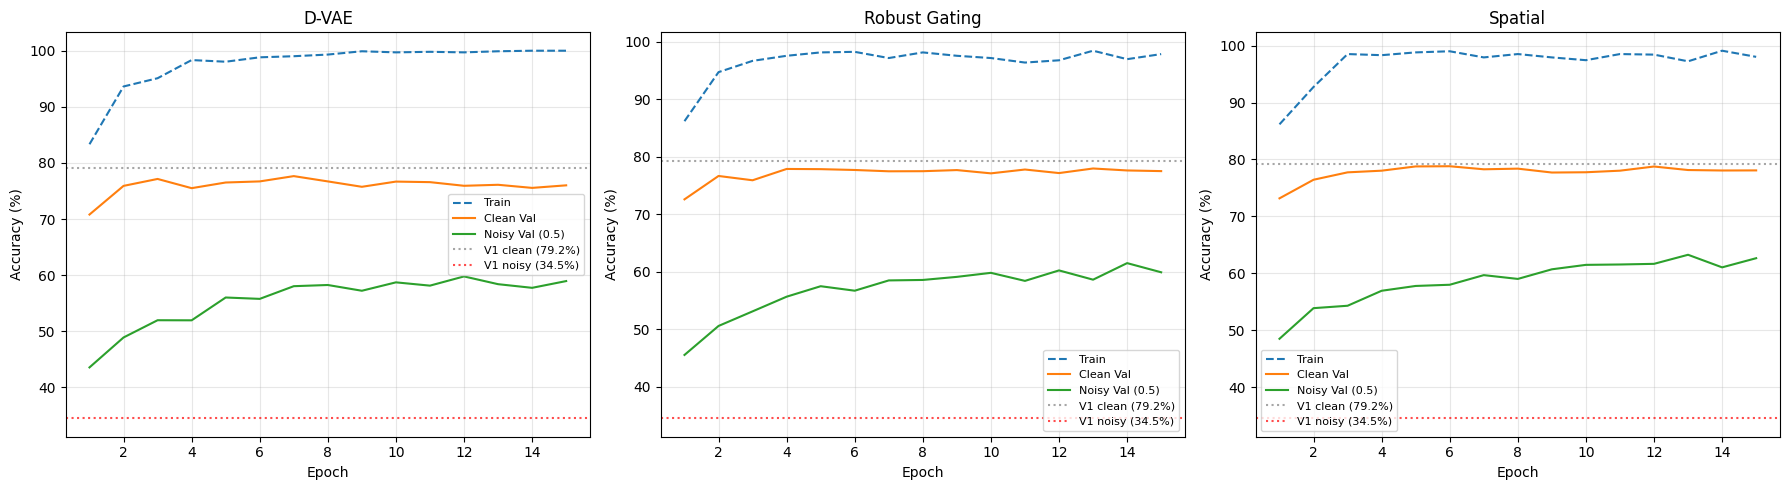

In [16]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, EPOCHS + 1)

for ax, (name, hist) in zip(axes, [('D-VAE', history_dvae), ('Robust Gating', history_robust), ('Spatial', history_spatial)]):
    ax.plot(epochs_range, hist['train_acc'], '--', label='Train')
    ax.plot(epochs_range, hist['clean_acc'], '-', label='Clean Val')
    ax.plot(epochs_range, hist['noisy_acc'], '-', label='Noisy Val (0.5)')
    ax.axhline(y=v1_clean, color='gray', linestyle=':', alpha=0.7, label=f'V1 clean ({v1_clean:.1f}%)')
    ax.axhline(y=v1_noisy, color='red', linestyle=':', alpha=0.7, label=f'V1 noisy ({v1_noisy:.1f}%)')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

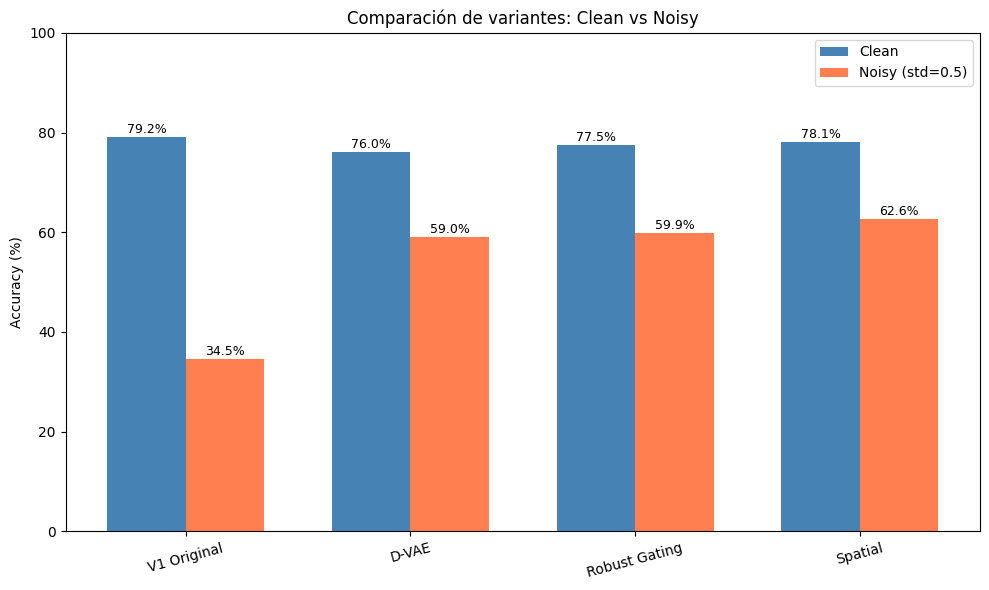

In [17]:
# Bar chart comparativo
names = list(results.keys())
clean_accs = [results[n]['clean'] for n in names]
noisy_accs = [results[n]['noisy'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, clean_accs, width, label='Clean', color='steelblue')
bars2 = ax.bar(x + width/2, noisy_accs, width, label='Noisy (std=0.5)', color='coral')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparación de variantes: Clean vs Noisy')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.legend()
ax.set_ylim(0, 100)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# Guardar los mejores checkpoints
os.makedirs('../out', exist_ok=True)

for name, model in [('dvae', model_dvae), ('robust_gate', model_robust), ('spatial', model_spatial)]:
    path = f'../out/dememte_{name}_flowers102.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'metadata': {
            'variant': name,
            'dataset': 'Flowers102',
            'epochs': EPOCHS,
            'noise_std_train': NOISE_STD,
            'clean_acc': results[{'dvae': 'D-VAE', 'robust_gate': 'Robust Gating', 'spatial': 'Spatial'}[name]]['clean'],
            'noisy_acc': results[{'dvae': 'D-VAE', 'robust_gate': 'Robust Gating', 'spatial': 'Spatial'}[name]]['noisy'],
        }
    }, path)
    print(f'Saved {path}')

print('\nTodos los checkpoints guardados en ../out/')

Saved ../out/dememte_dvae_flowers102.pth
Saved ../out/dememte_robust_gate_flowers102.pth
Saved ../out/dememte_spatial_flowers102.pth

Todos los checkpoints guardados en ../out/
